# Product Category Classifier — Training & Evaluation

Fine-tunes a ResNet-50 on Open Beauty Facts images to classify products into
**skincare**, **makeup**, or **haircare**.

---
## Setup

In [1]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import sys, json, random
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from classifier.dataset import ProductDataset
from classifier.categories import CATEGORY_MAP

## 0. Build Datasets


In [3]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.build_dataset"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Classified 10,215 products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\raw\manifest.csv
Downloaded 0/4 new images

Download summary:
  skincare: 6898
  haircare: 2498
  makeup: 819

Total: 10215 images



In [6]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.collect_unlabeled"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Found 54,922 unlabeled products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\unlabeled\unlabeled_manifest.csv
Downloaded 0/14 unlabeled images

Total unlabeled images available: 55012



## 1. Load Datasets

Train: 9525 | Train-dev: 1679 | Val: 2400 | Test: 2400
Classes: ['haircare', 'makeup', 'skincare']

Train-dev class distribution:
  haircare: 735 (43.8%)
  makeup: 97 (5.8%)
  skincare: 847 (50.4%)
haircare: 4904
makeup: 651
skincare: 5649


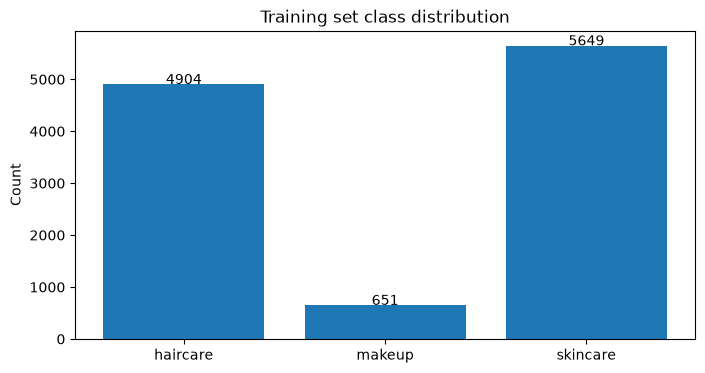

In [8]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

train_ds = ProductDataset(DATA_DIR, split="train")
val_ds   = ProductDataset(DATA_DIR, split="val")
test_ds  = ProductDataset(DATA_DIR, split="test")

# Create train-dev split: hold out 15% of training data, stratified by class
from torch.utils.data import Subset

def stratified_split(dataset, dev_pct=0.15, seed=42):
    """Return (train_indices, dev_indices) with stratified class distribution."""
    class_indices = {}
    for i, (_, label) in enumerate(dataset.samples):
        class_indices.setdefault(label, []).append(i)
    rng = random.Random(seed)
    train_idx, dev_idx = [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n_dev = max(1, int(len(indices) * dev_pct))
        dev_idx.extend(indices[:n_dev])
        train_idx.extend(indices[n_dev:])
    return train_idx, dev_idx

train_idx, train_dev_idx = stratified_split(train_ds)
train_dev_ds = Subset(train_ds, train_dev_idx)
train_ds_sub = Subset(train_ds, train_idx)

train_loader = DataLoader(train_ds_sub, 32, shuffle=False)
train_dev_loader = DataLoader(train_dev_ds, 32, shuffle=False)
val_loader = DataLoader(val_ds, 32, shuffle=False)
test_loader = DataLoader(test_ds, 32, shuffle=False)

print(f"Train: {len(train_ds_sub)} | Train-dev: {len(train_dev_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {train_ds.classes}")

# Verify train-dev stratification
td_counts = [sum(1 for i in train_dev_idx if train_ds.samples[i][1] == c)
             for c in range(len(train_ds.classes))]
print("\nTrain-dev class distribution:")
for cls, cnt in zip(train_ds.classes, td_counts):
    print(f"  {cls}: {cnt} ({cnt/len(train_dev_ds)*100:.1f}%)")

# Class distribution bar chart
counts = [sum(1 for _, l in train_ds.samples if l == i) for i in range(len(train_ds.classes))]
for cls, cnt in zip(train_ds.classes, counts):
    print(f"{cls}: {cnt}")
plt.figure(figsize=(8, 4))
plt.bar(train_ds.classes, counts)
plt.title("Training set class distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

## 2. Train Model

In [9]:
from classifier.train import train_model

LOAD_FROM_DISK = True

MODEL_DIR = DATA_DIR.parent / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "resnet50_product_category.pt"

CKPT_DIR = MODEL_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if LOAD_FROM_DISK and MODEL_PATH.exists() and (MODEL_DIR / "history.json").exists():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(2048, len(train_ds.classes))
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    model.to(DEVICE)
    with open(MODEL_DIR / "history.json") as f:
        history = json.load(f)
    best_acc = max(history["val_acc"])
    print(f"Loaded model + history from disk (best_acc={best_acc:.2f}%)")
else:
    model, history, best_acc = train_model(
        train_ds_sub, val_ds, DEVICE,
        epochs=20,
        unfreeze_layers=14,
        num_workers=0,
        checkpoint_every=5,
        checkpoint_dir=CKPT_DIR,
    )
    print(f"\nBest validation accuracy: {best_acc:.2f}%")
    torch.save(model.state_dict(), MODEL_PATH)
    with open(MODEL_DIR / "history.json", "w") as f:
        json.dump(history, f)
    print(f"Model + history saved to {MODEL_DIR}")

Train: 9525 | Val: 2400 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/20: 100%|██████████| 298/298 [01:19<00:00,  3.73it/s]


  Loss: 0.7947 / 0.7389 | Val Acc: 73.25% | LR: 1.00e-04


Epoch 2/20: 100%|██████████| 298/298 [01:19<00:00,  3.77it/s]


  Loss: 0.6806 / 0.7173 | Val Acc: 73.75% | LR: 1.00e-04


...

  Loss: 0.4824 / 0.7020 | Val Acc: 77.04% | LR: 5.00e-05


Epoch 15/20: 100%|██████████| 298/298 [01:24<00:00,  3.52it/s]


  Loss: 0.4650 / 0.6976 | Val Acc: 77.79% | LR: 2.50e-05


Epoch 16/20: 100%|██████████| 298/298 [01:17<00:00,  3.86it/s]


  Loss: 0.4669 / 0.6868 | Val Acc: 77.96% | LR: 2.50e-05
  Early stopping triggered (no improvement for 5 epochs)

Best validation accuracy: 78.38%
Model + history saved to c:\Projects\cosmetic-expiry-scanner\backend\data\models


## 3. Training Curves

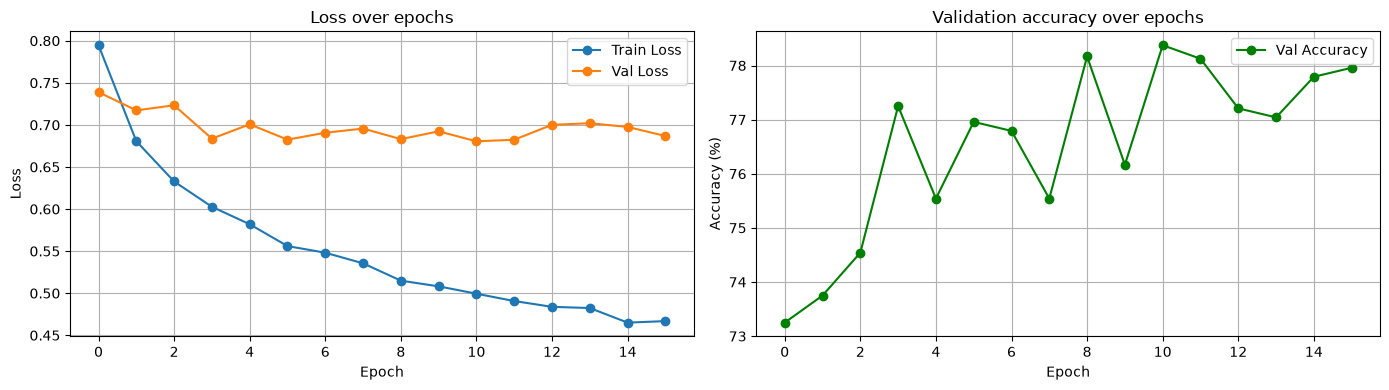

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history["val_acc"], label="Val Accuracy", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Test Set Evaluation

Testing: 100%|██████████| 75/75 [00:07<00:00,  9.46it/s]


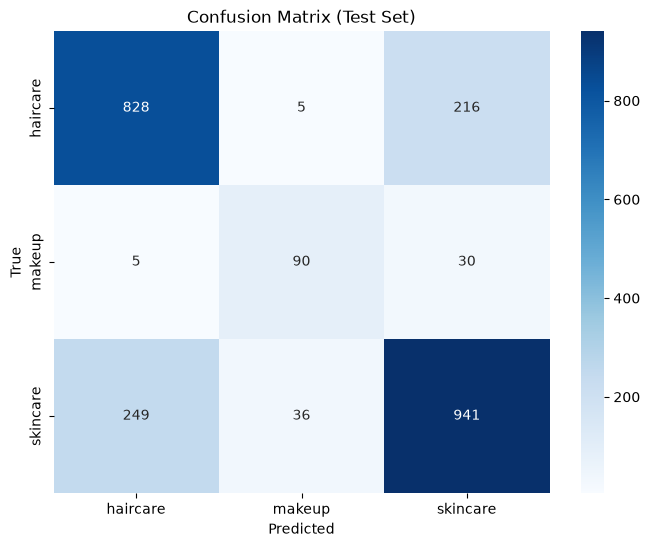

              precision    recall  f1-score   support

    haircare       0.77      0.79      0.78      1049
      makeup       0.69      0.72      0.70       125
    skincare       0.79      0.77      0.78      1226

    accuracy                           0.77      2400
   macro avg       0.75      0.76      0.75      2400
weighted avg       0.78      0.77      0.77      2400



In [11]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Per-class metrics
print(classification_report(all_labels, all_preds,
                            target_names=train_ds.classes))

## 5. Checkpoint Evaluation

Evaluate each saved checkpoint on train-dev and validation sets to find the divergence point.

In [12]:
import pandas as pd
test_rows = [{"epoch": 5, "train_loss": 0.5, "val_error_%": 20.0, "train_dev_error_%": 25.0}]
test_df = pd.DataFrame(test_rows).sort_values("epoch")
print(test_df.to_string(index=False))

 epoch  train_loss  val_error_%  train_dev_error_%
     5         0.5         20.0               25.0


In [13]:
import torch
from torchvision import models
import torch.nn as nn
import pandas as pd

# Load a model onto DEVICE, same as Section 5 does
m = models.resnet50(weights=None)
m.fc = nn.Linear(2048, len(train_ds.classes))
m.to(DEVICE)
m.eval()

# Now try the pandas call while that model is alive in memory / on GPU
test_rows = [{"epoch": 5, "train_loss": 0.5, "val_error_%": 20.0, "train_dev_error_%": 25.0}]
test_df = pd.DataFrame(test_rows).sort_values("epoch")
print(test_df.to_string(index=False))
print("Survived")

 epoch  train_loss  val_error_%  train_dev_error_%
     5         0.5         20.0               25.0
Survived


In [14]:
import glob as glob_mod
import gc

ckpt_paths = sorted(glob_mod.glob(str(CKPT_DIR / "checkpoint_epoch_*.pt")))
if ckpt_paths:
    ckpt_rows = []
    for ckpt_path in ckpt_paths:
        epoch_num = int(Path(ckpt_path).stem.split("_")[-1])
        ckpt_model = models.resnet50(weights=None)
        ckpt_model.fc = nn.Linear(2048, len(train_ds.classes))
        ckpt_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        ckpt_model.to(DEVICE)
        ckpt_model.eval()

        # Train-dev error
        td_correct = td_total = 0
        with torch.no_grad():
            for imgs, lbls in train_dev_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                _, preds = ckpt_model(imgs).max(1)
                td_correct += (preds == lbls).sum().item()
                td_total += lbls.size(0)
        td_err = 100.0 * (1 - td_correct / td_total)

        # Val error from history if available
        if epoch_num <= len(history["val_acc"]):
            val_err = 100.0 - history["val_acc"][epoch_num - 1]
        else:
            v_correct = v_total = 0
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                    _, preds = ckpt_model(imgs).max(1)
                    v_correct += (preds == lbls).sum().item()
                    v_total += lbls.size(0)
            val_err = 100.0 * (1 - v_correct / v_total)

        # Free memory before next iteration
        del ckpt_model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        train_loss = history["train_loss"][epoch_num - 1] if epoch_num <= len(history["train_loss"]) else None
        ckpt_rows.append({
            "epoch": epoch_num,
            "train_loss": round(train_loss, 4) if train_loss else None,
            "val_error_%": round(val_err, 2),
            "train_dev_error_%": round(td_err, 2),
        })

    ckpt_df = pd.DataFrame(ckpt_rows).sort_values("epoch")
    print(ckpt_df.to_string(index=False))
else:
    print("No checkpoints found. Run training with checkpoint_every > 0 to generate them.")

 epoch  train_loss  val_error_%  train_dev_error_%
     5      0.5819        24.46              27.22
    10      0.5081        23.83              25.07
    15      0.4650        22.21              24.06


## 6. Sample Predictions

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4054286..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..1.9064132].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.64].
Clipping

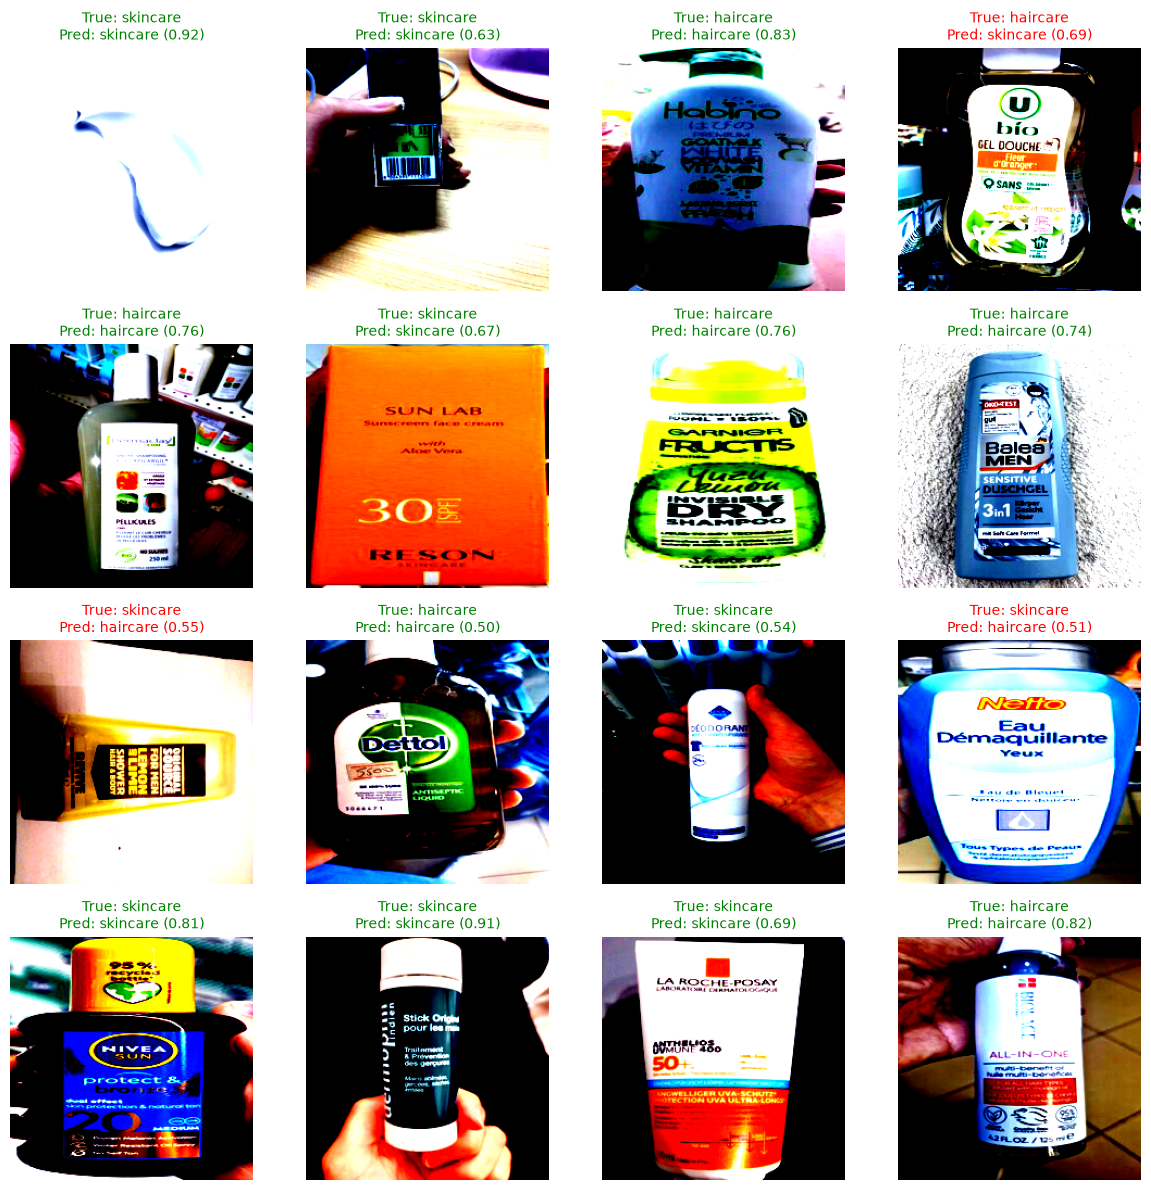

In [15]:
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[int(i)]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, 1)
        conf, pred = prob.max(1)
    true_label = train_ds.classes[label]
    pred_label = train_ds.classes[pred.item()]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.cpu().numpy().transpose((1, 2, 0)))
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf.item():.2f})",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Error Analysis

Human-level error estimated by personally labeling 78 examples using the HLE pipeline.

In [16]:
with open(MODEL_DIR / "hle_results.json") as f:
    hle = json.load(f)

print("=" * 68)
print("HUMAN-LEVEL ERROR ESTIMATION RESULTS")
print("=" * 68)
print(f"  Total examples:        {hle['total_examples']}")
print(f"  Human error (vs GT):   {hle['human_error_pct']}%  ({hle['human_errors']}/{hle['total_examples']})")
print(f"  Model error (vs GT):   {hle['model_error_pct']}%  ({hle['model_errors']}/{hle['total_examples']})")
print(f"  Human-model agreement: {hle['human_model_agreement_pct']}%")
print()
print("-" * 68)
print("PER-CLASS BREAKDOWN")
print("-" * 68)
print(f"  {'Class':<12} {'Count':>5}  {'Human Err':>10}  {'Model Err':>10}")
print(f"  {'-'*12} {'-'*5}  {'-'*10}  {'-'*10}")
for cls, data in hle["per_class"].items():
    print(f"  {cls:<12} {data['count']:>5}  {data['human_error_pct']:>9.1f}%  {data['model_error_pct']:>9.1f}%")
print()
print("=" * 68)

HUMAN-LEVEL ERROR ESTIMATION RESULTS
  Total examples:        78
  Human error (vs GT):   6.4%  (5/78)
  Model error (vs GT):   23.1%  (18/78)
  Human-model agreement: 75.6%

--------------------------------------------------------------------
PER-CLASS BREAKDOWN
--------------------------------------------------------------------
  Class        Count   Human Err   Model Err
  ------------ -----  ----------  ----------
  haircare        18        0.0%       27.8%
  makeup           6        0.0%        0.0%
  skincare        54        9.3%       24.1%



## 8. Error Comparison: All Splits vs Human-Level Error

Programmatic table computed from model predictions on each split.

In [18]:
def eval_error(model, loader, device):
    """Compute error rate (%) for model on loader."""
    correct = total = 0
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, preds = model(imgs).max(1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return 100.0 * (1 - correct / total)

train_err = eval_error(model, train_loader, DEVICE)
train_dev_err = eval_error(model, train_dev_loader, DEVICE)
dev_err = eval_error(model, val_loader, DEVICE)
test_err = eval_error(model, test_loader, DEVICE)

with open(MODEL_DIR / "hle_results.json") as f:
    hle = json.load(f)
hle_err = hle["human_error_pct"]

def fmt_gap(val, ref):
    diff = val - ref
    sign = "+" if diff >= 0 else ""
    return f"{sign}{diff:.2f}%"

rows = [
    {"Split": "HLE (Bayes Error)", "Error %": hle_err,
     "Gap to HLE": "--", "Adjacent Gap": "--", "Diagnosis": "Human baseline"},
    {"Split": "Train", "Error %": round(train_err, 2),
     "Gap to HLE": fmt_gap(train_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_err, hle_err)} (vs HLE)",
     "Diagnosis": "Avoidable bias"},
    {"Split": "Train-dev", "Error %": round(train_dev_err, 2),
     "Gap to HLE": fmt_gap(train_dev_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_dev_err, train_err)} (vs Train)",
     "Diagnosis": "Variance" if abs(train_dev_err - train_err) > 1 else "Variance -- negligible"},
    {"Split": "Dev (Val)", "Error %": round(dev_err, 2),
     "Gap to HLE": fmt_gap(dev_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(dev_err, train_dev_err)} (vs Train-dev)",
     "Diagnosis": "Data mismatch"},
    {"Split": "Test", "Error %": round(test_err, 2),
     "Gap to HLE": fmt_gap(test_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(test_err, dev_err)} (vs Dev)",
     "Diagnosis": "Consistent with dev"},
]

error_df = pd.DataFrame(rows)
print(error_df.to_string(index=False))

print("\n**Key Insights:**")
print(f"1. Bayes/Train gap ({fmt_gap(train_err, hle_err)}) is the avoidable bias.")
td_gap = train_dev_err - train_err
print(f"2. Train/Train-dev gap ({td_gap:+.2f}%) is {'negligible -- rules out variance' if abs(td_gap) < 1 else 'significant'}.")
mismatch_gap = dev_err - train_dev_err
print(f"3. Train-dev/Dev gap ({mismatch_gap:+.2f}%) is {'the largest -- data mismatch' if mismatch_gap > 5 else 'moderate'}.")
dev_test_gap = test_err - dev_err
print(f"4. Dev/Test gap ({dev_test_gap:+.2f}%) is {'negligible -- dev and test consistent' if abs(dev_test_gap) < 2 else 'notable'}.")

            Split  Error % Gap to HLE          Adjacent Gap           Diagnosis
HLE (Bayes Error)     6.40         --                    --      Human baseline
            Train    13.47     +7.07%       +7.07% (vs HLE)      Avoidable bias
        Train-dev    24.00    +17.60%    +10.53% (vs Train)            Variance
        Dev (Val)    21.63    +15.23% -2.38% (vs Train-dev)       Data mismatch
             Test    22.54    +16.14%       +0.92% (vs Dev) Consistent with dev

**Key Insights:**
1. Bayes/Train gap (+7.07%) is the avoidable bias.
2. Train/Train-dev gap (+10.53%) is significant.
3. Train-dev/Dev gap (-2.38%) is moderate.
4. Dev/Test gap (+0.92%) is negligible -- dev and test consistent.


## 9. Extended Training -- Bias Investigation

Train for more epochs (40) with checkpoints every 5 epochs to find where
train-dev error starts climbing (divergence point = overfitting indicator).

In [19]:
EXTENDED_EPOCHS = 40
EXTENDED_CKPT_DIR = MODEL_DIR / "extended_checkpoints"
EXTENDED_CKPT_DIR.mkdir(parents=True, exist_ok=True)
EXTENDED_HISTORY_PATH = MODEL_DIR / "extended_history.json"

if LOAD_FROM_DISK and EXTENDED_HISTORY_PATH.exists() and any(EXTENDED_CKPT_DIR.glob("checkpoint_epoch_*.pt")):
    with open(EXTENDED_HISTORY_PATH) as f:
        ext_history = json.load(f)
    print(f"Loaded extended training history ({len(ext_history['val_acc'])} epochs) from disk")
else:
    ext_model, ext_history, ext_best_acc = train_model(
        train_ds_sub, val_ds, DEVICE,
        epochs=EXTENDED_EPOCHS,
        unfreeze_layers=14,
        num_workers=0,
        checkpoint_every=5,
        checkpoint_dir=EXTENDED_CKPT_DIR,
        patience=40,
    )
    torch.save(ext_model.state_dict(), MODEL_DIR / "resnet50_extended.pt")
    with open(EXTENDED_HISTORY_PATH, "w") as f:
        json.dump(ext_history, f)
    print(f"Extended training complete. Best val accuracy: {ext_best_acc:.2f}%")

Train: 9525 | Val: 2400 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/40: 100%|██████████| 298/298 [01:19<00:00,  3.74it/s]


  Loss: 0.8102 / 0.7470 | Val Acc: 72.62% | LR: 1.00e-04


Epoch 2/40: 100%|██████████| 298/298 [01:16<00:00,  3.91it/s]


  Loss: 0.6813 / 0.7197 | Val Acc: 74.79% | LR: 1.00e-04


...

  Loss: 0.4363 / 0.7107 | Val Acc: 78.46% | LR: 7.81e-07


Epoch 39/40: 100%|██████████| 298/298 [01:16<00:00,  3.90it/s]


  Loss: 0.4346 / 0.7109 | Val Acc: 78.17% | LR: 3.91e-07


Epoch 40/40: 100%|██████████| 298/298 [01:15<00:00,  3.93it/s]


  Loss: 0.4377 / 0.7102 | Val Acc: 77.88% | LR: 3.91e-07
Extended training complete. Best val accuracy: 79.17%


## 10. Extended Checkpoint Evaluation

Evaluate extended checkpoints on train-dev to find the divergence point.

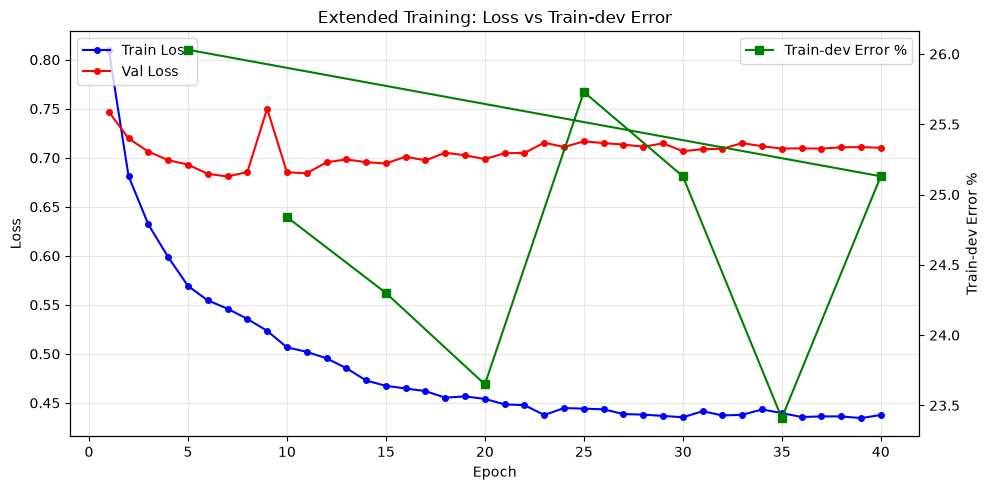

Lowest train-dev error: 23.41% at epoch 35


In [20]:
ext_ckpt_paths = sorted(EXTENDED_CKPT_DIR.glob("checkpoint_epoch_*.pt"))
ext_rows = []
for p in ext_ckpt_paths:
    ep = int(p.stem.split("_")[-1])
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(2048, len(train_ds.classes))
    m.load_state_dict(torch.load(p, map_location=DEVICE, weights_only=True))
    m.to(DEVICE)
    m.eval()
    td_c = td_t = 0
    with torch.no_grad():
        for imgs, lbls in train_dev_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            _, pr = m(imgs).max(1)
            td_c += (pr == lbls).sum().item()
            td_t += lbls.size(0)
    # Free memory before next iteration
    del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    ext_rows.append({"epoch": ep, "train_dev_error_%": round(100*(1-td_c/td_t), 2)})

ext_df = pd.DataFrame(ext_rows)

# Plot train loss, val loss, train-dev error together
fig, ax1 = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(ext_history["train_loss"]) + 1)
ax1.plot(epochs_range, ext_history["train_loss"], "b-o", label="Train Loss", markersize=4)
ax1.plot(epochs_range, ext_history["val_loss"], "r-o", label="Val Loss", markersize=4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ext_df["epoch"], ext_df["train_dev_error_%"], "g-s", label="Train-dev Error %", markersize=6)
ax2.set_ylabel("Train-dev Error %")
ax2.legend(loc="upper right")

plt.title("Extended Training: Loss vs Train-dev Error")
plt.tight_layout()
plt.show()

best_td_epoch = int(ext_df.loc[ext_df["train_dev_error_%"].idxmin(), "epoch"])
best_td_err = ext_df["train_dev_error_%"].min()
print(f"Lowest train-dev error: {best_td_err:.2f}% at epoch {best_td_epoch}")

## 11. Load Best Extended Checkpoint

In [21]:
best_ext_path = EXTENDED_CKPT_DIR / f"checkpoint_epoch_{best_td_epoch}.pt"
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(train_ds.classes))
model.load_state_dict(torch.load(best_ext_path, map_location=DEVICE, weights_only=True))
model.to(DEVICE)
model.eval()
print(f"Loaded epoch-{best_td_epoch} checkpoint as working model")

# Also save as the canonical best model for downstream use
torch.save(model.state_dict(), MODEL_DIR / "resnet50_best_biasrun.pt")
print(f"Saved as {MODEL_DIR / 'resnet50_best_biasrun.pt'}")

Loaded epoch-35 checkpoint as working model
Saved as c:\Projects\cosmetic-expiry-scanner\backend\data\models\resnet50_best_biasrun.pt


## 12. Extended Error Comparison

In [22]:
train_err_ext = eval_error(model, train_loader, DEVICE)
train_dev_err_ext = eval_error(model, train_dev_loader, DEVICE)
dev_err_ext = eval_error(model, val_loader, DEVICE)
test_err_ext = eval_error(model, test_loader, DEVICE)

rows_ext = [
    {"Split": "HLE (Bayes Error)", "Error %": hle_err,
     "Gap to HLE": "--", "Adjacent Gap": "--", "Diagnosis": "Human baseline"},
    {"Split": "Train", "Error %": round(train_err_ext, 2),
     "Gap to HLE": fmt_gap(train_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_err_ext, hle_err)} (vs HLE)",
     "Diagnosis": "Avoidable bias"},
    {"Split": "Train-dev", "Error %": round(train_dev_err_ext, 2),
     "Gap to HLE": fmt_gap(train_dev_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_dev_err_ext, train_err_ext)} (vs Train)",
     "Diagnosis": "Variance" if abs(train_dev_err_ext - train_err_ext) > 1 else "Variance -- negligible"},
    {"Split": "Dev (Val)", "Error %": round(dev_err_ext, 2),
     "Gap to HLE": fmt_gap(dev_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(dev_err_ext, train_dev_err_ext)} (vs Train-dev)",
     "Diagnosis": "Data mismatch"},
    {"Split": "Test", "Error %": round(test_err_ext, 2),
     "Gap to HLE": fmt_gap(test_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(test_err_ext, dev_err_ext)} (vs Dev)",
     "Diagnosis": "Consistent with dev"},
]

error_df_ext = pd.DataFrame(rows_ext)
print(error_df_ext.to_string(index=False))
print(f"\nBest extended model: epoch {best_td_epoch}, train-dev error {best_td_err:.2f}%")

            Split  Error % Gap to HLE          Adjacent Gap           Diagnosis
HLE (Bayes Error)     6.40         --                    --      Human baseline
            Train     8.56     +2.16%       +2.16% (vs HLE)      Avoidable bias
        Train-dev    23.88    +17.48%    +15.33% (vs Train)            Variance
        Dev (Val)    22.25    +15.85% -1.63% (vs Train-dev)       Data mismatch
             Test    23.08    +16.68%       +0.83% (vs Dev) Consistent with dev

Best extended model: epoch 35, train-dev error 23.41%
